# 04 — Factor Timing with Sentiment Signals

This is the core analysis notebook. We test whether **WSJ news sentiment** and
**Reddit/WallStreetBets sentiment** improve an equal-weight factor portfolio
via walk-forward factor timing.

## Research Design

The key methodological choice is comparing each sentiment model against a **matched
macro-only control** run on the same data window. This isolates the marginal value
of sentiment, holding model class constant.

**Two sentiment windows (separate experiments):**
- WSJ: 2000-03 → 2017-06 (208 months, min 60-month training window)
- Reddit/WSB: 2013-01 → 2025-11 (156 months, min 36-month training window)

**Six model variants per sentiment source:**
| Model | Type | Features |
|---|---|---|
| F0A (control) | Signal-scaled EWP | Macro only |
| F0D (control) | Mean-variance (MV) | Macro only |
| 5A | Signal-scaled EWP, market-level | Macro + sentiment |
| 5B | Signal-scaled EWP, factor-specific | Macro + sentiment |
| 5C | Two-state MV (full/half), market-level | Macro + sentiment |
| 5D | MV factor-specific (Ledoit-Wolf + TC penalty) | Macro + sentiment |
| 5E | Random Forest, market-level | Macro + sentiment |
| 5F | Random Forest, factor-specific | Macro + sentiment |

**All models use:**
- Expanding-window walk-forward (no random splits)
- Expanding z-score standardization (no look-ahead)
- Net factor returns as targets (TC already deducted at 30bps × turnover)

## Sections
1. Config & Imports
2. Data Load
3. Baseline Equal-Weight Portfolio
4. Confidence-Derived Features (Reddit)
5. Signal Construction (Expanding Z-Score)
6. Walk-Forward Engine
7. Model Functions (Ridge: 5A–5D, RF: 5E–5F)
8. Run All Experiments
9. Results Table
10. Visualizations

## 1. Config & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.linear_model import RidgeCV
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm

from utils import sharpe, make_ewp, evaluate

np.random.seed(42)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

# ── Experiment configs ──────────────────────────────────────────────────────
CFG_WSJ = {
    'name': 'WSJ',
    'sentiment_cols': ['wsj_index', 'wsj_uncertainty', 'topic_index', 'topic_uncertainty'],
    'start': '2000-03-31',
    'end':   '2017-06-30',
    'min_train_months': 60,
}
CFG_REDDIT = {
    'name': 'Reddit',
    'sentiment_cols': ['WallStreetBets_score', 'WallStreetBets_numeric_score', 'WallStreetBets_confidence'],
    'start': '2013-01-31',
    'end':   '2025-12-31',
    'min_train_months': 36,
}

# Factor net returns (TC already deducted)
FACTOR_COLS   = ['fac_value_net','fac_momentum_net','fac_quality_net','fac_investment_net','fac_size_net']
FACTOR_LABELS = ['Value','Momentum','Quality','Investment','Size']
N_FACTORS     = len(FACTOR_COLS)

# Macro controls used in ALL models
MACRO_COLS    = ['mktrf', 'term_spread_10y_fedfunds', 'mkt_vol_12m', 'dispersion']

# Model hyperparameters
RIDGE_ALPHAS  = [0.01, 0.1, 1.0, 10.0, 100.0]
GAMMA         = 3.0    # MV risk aversion
TC_PENALTY    = 2.0    # Turnover penalty κ for 5D: w* = (γΣ + κI)⁻¹(μ + κ·w_prev)
RF_DEPTHS     = [1, 2, 3]
RF_ESTIMATORS = 500
RF_LEAF_FRAC  = 0.10

DATA_PATH = 'data/FinalMonthlyDataset_ours_ff_macro.csv'
print('Config loaded. TC_PENALTY =', TC_PENALTY)

Config loaded. TC_PENALTY = 2.0


## 2. Data Load

In [2]:
def load_and_clean(path):
    """
    Load the final monthly dataset, set a DatetimeIndex,
    and cast any nullable Float64 columns to float64 for sklearn compatibility.
    """
    df = pd.read_csv(path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.set_index('date').sort_index()
    # Drop the forward-looking row (no returns available yet)
    df = df[df.index < '2026-01-01']
    for col in df.columns:
        if str(df[col].dtype) == 'Float64':
            df[col] = df[col].astype('float64')
    return df


df = load_and_clean(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min().date()} → {df.index.max().date()}')
print(f'\nFactor net return NaNs:')
print(df[FACTOR_COLS].isna().sum())
print(f'\nMacro control NaNs:')
macro_available = [c for c in MACRO_COLS if c in df.columns]
print(df[macro_available].isna().sum())

Shape: (310, 47)
Date range: 2000-03-31 → 2025-12-31

Factor net return NaNs:
fac_value_net          7
fac_momentum_net      11
fac_quality_net       22
fac_investment_net    19
fac_size_net           0
dtype: int64

Macro control NaNs:
mktrf                       0
term_spread_10y_fedfunds    0
mkt_vol_12m                 7
dispersion                  0
dtype: int64


## 3. Baseline Equal-Weight Portfolio

The equal-weight portfolio (EWP) — equal allocation to all five factors each month — is
the benchmark every timing model must beat. It is difficult to improve upon in practice
because it is already diversified and has no estimation error in the weights.

In [3]:
ewp_full   = make_ewp(df, FACTOR_COLS)
ewp_wsj    = make_ewp(df, FACTOR_COLS, CFG_WSJ['start'],    CFG_WSJ['end'])
ewp_reddit = make_ewp(df, FACTOR_COLS, CFG_REDDIT['start'], CFG_REDDIT['end'])

print('Equal-Weight Portfolio Sharpe ratios:')
print(f'  Full sample (2000-03 → 2025-11) : {sharpe(ewp_full):.3f}')
print(f'  WSJ window  (2000-03 → 2017-06) : {sharpe(ewp_wsj):.3f}')
print(f'  Reddit window (2013-01 → 2025-11): {sharpe(ewp_reddit):.3f}')

print('\nPer-factor net Sharpe (full sample):')
for col, lbl in zip(FACTOR_COLS, FACTOR_LABELS):
    if col in df.columns:
        print(f'  {lbl:12s}: {sharpe(df[col].dropna()):.3f}')

Equal-Weight Portfolio Sharpe ratios:
  Full sample (2000-03 → 2025-11) : 0.266
  WSJ window  (2000-03 → 2017-06) : 0.412
  Reddit window (2013-01 → 2025-11): -0.179

Per-factor net Sharpe (full sample):
  Value       : 0.273
  Momentum    : 0.129
  Quality     : 0.034
  Investment  : 0.131
  Size        : 0.068


## 4. Confidence-Derived Features (Reddit)

A key finding from exploratory analysis: the raw Reddit `avg_confidence` signal is a
classifier softmax output averaged over hundreds of posts per month. This averaging
compresses variance (range ≈ 0.665–0.741, std ≈ 0.015).

Empirically, the sentiment signal is **stronger in low-confidence months** — when the
classifier is uncertain, the small directional signal is more forward-looking. High
confidence typically corresponds to clearly negative sentiment (bear market), which is
already priced in. This is consistent with Cookson et al. (2024).

We engineer two confidence-gated features:
1. `conf_gated_sent`: full sentiment in uncertain months, 0 in certain months
2. `conf_inv_sent`: sentiment weighted by how far confidence falls below its rolling median

In [4]:
reddit_cols_available = [c for c in ['WallStreetBets_confidence', 'WallStreetBets_score'] if c in df.columns]

if len(reddit_cols_available) == 2:
    reddit_raw = df.loc[CFG_REDDIT['start']:CFG_REDDIT['end'], reddit_cols_available].copy()

    # Expanding statistics — no look-ahead
    conf_med_exp = reddit_raw['WallStreetBets_confidence'].expanding(min_periods=12).median()
    conf_std_exp = reddit_raw['WallStreetBets_confidence'].expanding(min_periods=12).std()

    # Feature 1: Binary confidence gate
    df['conf_gated_sent'] = np.nan
    df.loc[reddit_raw.index, 'conf_gated_sent'] = np.where(
        reddit_raw['WallStreetBets_confidence'] < conf_med_exp,
        reddit_raw['WallStreetBets_score'], 0.0
    )

    # Feature 2: Graduated inverse-confidence weighting
    conf_below = (conf_med_exp - reddit_raw['WallStreetBets_confidence']).clip(lower=0)
    df['conf_inv_sent'] = np.nan
    df.loc[reddit_raw.index, 'conf_inv_sent'] = (
        reddit_raw['WallStreetBets_score'] * conf_below / conf_std_exp.replace(0, np.nan)
    )

    CFG_REDDIT['sentiment_cols'] = [
        'WallStreetBets_score', 'WallStreetBets_numeric_score', 'WallStreetBets_confidence',
        'conf_gated_sent', 'conf_inv_sent',
    ]
    CFG_REDDIT['sentiment_cols'] = [c for c in CFG_REDDIT['sentiment_cols'] if c in df.columns]

    # Predictive correlation of each feature with next-month EWP
    ewp_next = df[FACTOR_COLS].mean(axis=1).shift(-1)
    print('Predictive correlation with next-month EWP return:')
    for col in CFG_REDDIT['sentiment_cols']:
        if col in df.columns:
            r = df[col].corr(ewp_next)
            print(f'  {col:30s}: r = {r:+.4f}')
else:
    print('Reddit confidence columns not available — using raw sentiment only.')
    CFG_REDDIT['sentiment_cols'] = [c for c in CFG_REDDIT['sentiment_cols'] if c in df.columns]

print('\nFinal CFG_REDDIT sentiment_cols:', CFG_REDDIT['sentiment_cols'])


Predictive correlation with next-month EWP return:
  WallStreetBets_score          : r = +0.0509
  WallStreetBets_numeric_score  : r = +0.0380
  WallStreetBets_confidence     : r = +0.0079
  conf_gated_sent               : r = -0.1381
  conf_inv_sent                 : r = -0.1459

Final CFG_REDDIT sentiment_cols: ['WallStreetBets_score', 'WallStreetBets_numeric_score', 'WallStreetBets_confidence', 'conf_gated_sent', 'conf_inv_sent']


## 5. Signal Construction (Expanding Z-Score)

All features are standardized using an **expanding z-score** before entering the models.
This is critical for avoiding look-ahead bias: at each time step `t`, we only use
the mean and standard deviation estimated from observations up to and including `t`.

In [5]:
def expanding_zscore(series):
    """Standardize using only past observations (no look-ahead)."""
    mu  = series.expanding(min_periods=12).mean()
    sig = series.expanding(min_periods=12).std()
    return (series - mu) / sig.replace(0, np.nan)


def make_signals(df, cfg):
    """Subset to the experiment window and expanding z-score all features."""
    sub = df.loc[cfg['start']:cfg['end']].copy()
    for col in cfg['sentiment_cols']:
        if col in sub.columns:
            sub[f'{col}_z'] = expanding_zscore(sub[col])
    macro_available = [c for c in MACRO_COLS if c in sub.columns]
    for col in macro_available:
        sub[f'{col}_z'] = expanding_zscore(sub[col])
    return sub


df_wsj    = make_signals(df, CFG_WSJ)
df_reddit = make_signals(df, CFG_REDDIT)

wsj_z_cols    = [f'{c}_z' for c in CFG_WSJ['sentiment_cols']    if f'{c}_z' in df_wsj.columns]
reddit_z_cols = [f'{c}_z' for c in CFG_REDDIT['sentiment_cols'] if f'{c}_z' in df_reddit.columns]
macro_z_cols  = [f'{c}_z' for c in MACRO_COLS if f'{c}_z' in df_wsj.columns]

print('WSJ sentiment z-cols:   ', wsj_z_cols)
print('Reddit sentiment z-cols:', reddit_z_cols)
print('Macro z-cols:           ', macro_z_cols)
print(f'\nWSJ window shape:    {df_wsj.shape}')
print(f'Reddit window shape: {df_reddit.shape}')

WSJ sentiment z-cols:    ['wsj_index_z', 'wsj_uncertainty_z', 'topic_index_z', 'topic_uncertainty_z']
Reddit sentiment z-cols: ['WallStreetBets_score_z', 'WallStreetBets_numeric_score_z', 'WallStreetBets_confidence_z', 'conf_gated_sent_z', 'conf_inv_sent_z']
Macro z-cols:            ['mktrf_z', 'term_spread_10y_fedfunds_z', 'mkt_vol_12m_z', 'dispersion_z']

WSJ window shape:    (208, 57)
Reddit window shape: (156, 58)


## 6. Walk-Forward Engine

At each month `t` (once the minimum training window is reached):
1. Train on all data up to `t-1` (expanding window)
2. Use features at `t-1` to predict returns at `t`
3. Record out-of-sample portfolio return and factor weights

Previous weights (`w_prev`) are threaded through iterations so that the MV model
(5D) can apply a turnover penalty.

In [6]:
def get_feature_matrix(sub_df, sentiment_z_cols, macro_z_cols, factor_cols, lag=True):
    """
    Build predictor matrix X and target matrix Y.
    X at time t predicts Y at time t+1 (lag=True).
    Returns (X, Y) with NaN rows removed.
    """
    feat_cols = sentiment_z_cols + macro_z_cols
    feat_cols = [c for c in feat_cols if c in sub_df.columns]
    target_cols_avail = [c for c in factor_cols if c in sub_df.columns]

    X = sub_df[feat_cols]
    Y = sub_df[target_cols_avail]

    if lag:
        X = X.iloc[:-1]
        Y = Y.iloc[1:]

    combined = pd.concat([X.reset_index(drop=True), Y.reset_index(drop=True)], axis=1).dropna()
    return combined[feat_cols].values, combined[target_cols_avail].values


def walk_forward(df_window, cfg, sentiment_z_cols, factor_cols, macro_z_cols, model_fn):
    """
    Expanding-window walk-forward evaluation.
    Returns (oos_returns Series, oos_weights DataFrame).
    """
    dates     = df_window.index
    min_train = cfg['min_train_months']
    feat_cols = [c for c in sentiment_z_cols + macro_z_cols if c in df_window.columns]
    fac_avail = [c for c in factor_cols if c in df_window.columns]

    oos_returns = {}
    oos_weights = {}
    w_prev = np.full(len(fac_avail), 1.0 / len(fac_avail))
    _first_error = None

    for i in range(min_train, len(dates)):
        t_date   = dates[i]
        train_df = df_window.iloc[:i]
        test_row = df_window.iloc[[i]]

        X_train, Y_train = get_feature_matrix(
            train_df, sentiment_z_cols, macro_z_cols, fac_avail, lag=True
        )
        x_test = train_df[feat_cols].iloc[[-1]].values

        if X_train.shape[0] < max(20, len(feat_cols) + 2):
            continue
        if np.isnan(x_test).any():
            continue

        try:
            weights = model_fn(X_train, Y_train, x_test,
                               n_factors=len(fac_avail), w_prev=w_prev)
        except Exception as e:
            if _first_error is None:
                _first_error = (t_date, e)
            continue

        r_t = test_row[fac_avail].values.flatten()
        if np.isnan(r_t).any():
            continue

        oos_returns[t_date] = float(weights @ r_t)
        oos_weights[t_date] = weights
        w_prev = weights.copy()

    if _first_error is not None and not oos_returns:
        t, e = _first_error
        print(f'  !! walk_forward: 0 OOS months. First error at {t.date()}: {type(e).__name__}: {e}')
    oos_ret_series = pd.Series(oos_returns, name='oos_return')
    oos_wt_df = pd.DataFrame(oos_weights, index=fac_avail).T
    oos_wt_df.index.name = 'date'
    return oos_ret_series, oos_wt_df


print('Walk-forward engine defined.')

Walk-forward engine defined.


## 7. Model Functions

All models share the same signature: `(X_train, Y_train, x_test, n_factors, w_prev) → weights`.

**Control models** use macro features only (sentiment_z_cols=[] in the run loop).
**Sentiment models** add sentiment z-scores to the same feature set.
This ensures any difference in performance is attributable to the sentiment signal,
not to model architecture differences.

In [7]:
def fit_ridge(X, y):
    """RidgeCV with time-series-aware 5-fold CV."""
    model = RidgeCV(alphas=RIDGE_ALPHAS, cv=TimeSeriesSplit(n_splits=5))
    model.fit(X, y)
    return model


# ── 5A / F0A: Signal-scaled EWP, market-level ──────────────────────────────
def model_signal_market(X_train, Y_train, x_test, n_factors, w_prev=None):
    """
    Predict composite EWP return → scale uniform exposure.
    w_i = (1/N)(1 + 0.5 × z_hat),  z_hat = winsorized ±2σ
    """
    ewp_train = Y_train.mean(axis=1)
    model = fit_ridge(X_train, ewp_train)
    pred  = model.predict(x_test)[0]
    pred_train = model.predict(X_train)
    z_hat = np.clip((pred - pred_train.mean()) / (pred_train.std() + 1e-8), -2, 2)
    base  = 1.0 / n_factors
    return np.clip(np.full(n_factors, base * (1 + 0.5 * z_hat)), 0, 2 * base)


# ── 5B: Signal-scaled EWP, factor-specific ─────────────────────────────────
def model_signal_factor(X_train, Y_train, x_test, n_factors, w_prev=None):
    """
    One Ridge per factor → cross-sectional predicted returns → tilts.
    w_f = 1/N + 0.3 × (1/N) × score_f,  score_f = cross-sectional z-score
    """
    preds = np.zeros(n_factors)
    for f in range(n_factors):
        y_f = Y_train[:, f]
        valid = ~np.isnan(y_f)
        if valid.sum() >= 20:
            preds[f] = fit_ridge(X_train[valid], y_f[valid]).predict(x_test)[0]
    scores  = np.clip((preds - preds.mean()) / (preds.std() + 1e-8), -2, 2)
    base    = 1.0 / n_factors
    weights = np.clip(base + 0.3 * base * scores, 0, None)
    total   = weights.sum()
    return weights / total if total > 1e-8 else np.full(n_factors, base)


# ── 5C: Two-state mean-variance, market-level ───────────────────────────────
def model_mv_market(X_train, Y_train, x_test, n_factors, w_prev=None):
    """
    Full EWP if composite prediction positive, half-exposure otherwise.
    """
    pred  = fit_ridge(X_train, Y_train.mean(axis=1)).predict(x_test)[0]
    scale = 1.0 if pred > 0 else 0.5
    return np.full(n_factors, scale / n_factors)


# ── 5D / F0D: MV factor-specific with Ledoit-Wolf Σ and TC penalty ─────────
def model_mv_factor(X_train, Y_train, x_test, n_factors, w_prev=None):
    """
    Penalized MV: w* = (γΣ + κI)⁻¹(μ̂ + κ·w_prev)
    κ = TC_PENALTY (smooths toward previous weights, reducing turnover).
    """
    if w_prev is None:
        w_prev = np.full(n_factors, 1.0 / n_factors)
    preds = np.zeros(n_factors)
    for f in range(n_factors):
        y_f = Y_train[:, f]
        valid = ~np.isnan(y_f)
        if valid.sum() >= 20:
            preds[f] = fit_ridge(X_train[valid], y_f[valid]).predict(x_test)[0]
    mask = ~np.isnan(Y_train).any(axis=1)
    if mask.sum() < n_factors + 5:
        return model_signal_factor(X_train, Y_train, x_test, n_factors, w_prev)
    Sigma   = LedoitWolf().fit(Y_train[mask]).covariance_
    A       = GAMMA * Sigma + TC_PENALTY * np.eye(n_factors)
    b       = preds + TC_PENALTY * w_prev
    weights = np.clip(np.linalg.solve(A, b), -0.5, 2.0)
    total   = weights.sum()
    return weights / total if total > 0 else np.full(n_factors, 1.0 / n_factors)


# ── RF helper ────────────────────────────────────────────────────────────────
def fit_rf(X, y, n_train):
    """
    Random Forest with depth CV over [1, 2, 3] and dynamic min_samples_leaf
    (10% of training window size, scales with expanding window).
    """
    min_leaf = max(1, int(RF_LEAF_FRAC * n_train))
    best_depth, best_score = 1, -np.inf
    if n_train >= 30:
        tscv = TimeSeriesSplit(n_splits=3)
        for depth in RF_DEPTHS:
            fold_scores = []
            for tr_idx, val_idx in tscv.split(X):
                if len(tr_idx) < min_leaf * 2: continue
                rf_cv = RandomForestRegressor(n_estimators=100, max_depth=depth,
                                             min_samples_leaf=min_leaf,
                                             max_features='sqrt', random_state=42, n_jobs=1)
                rf_cv.fit(X[tr_idx], y[tr_idx])
                fold_scores.append(rf_cv.score(X[val_idx], y[val_idx]))
            if fold_scores and np.mean(fold_scores) > best_score:
                best_score, best_depth = np.mean(fold_scores), depth
    rf = RandomForestRegressor(n_estimators=RF_ESTIMATORS, max_depth=best_depth,
                               min_samples_leaf=min_leaf, max_features='sqrt',
                               random_state=42, n_jobs=1)
    rf.fit(X, y)
    return rf


# ── 5E: RF, market-level ────────────────────────────────────────────────────
def model_rf_market(X_train, Y_train, x_test, n_factors, w_prev=None):
    """RF predicts composite EWP return → scale uniform exposure (mirrors 5A)."""
    ewp_train = Y_train.mean(axis=1)
    model     = fit_rf(X_train, ewp_train, len(X_train))
    pred      = model.predict(x_test)[0]
    pred_tr   = model.predict(X_train)
    z_hat     = np.clip((pred - pred_tr.mean()) / (pred_tr.std() + 1e-8), -2, 2)
    base      = 1.0 / n_factors
    return np.clip(np.full(n_factors, base * (1 + 0.5 * z_hat)), 0, 2 * base)


# ── 5F: RF, factor-specific ─────────────────────────────────────────────────
def model_rf_factor(X_train, Y_train, x_test, n_factors, w_prev=None):
    """One RF per factor → cross-sectional tilts (mirrors 5B)."""
    preds = np.zeros(n_factors)
    for f in range(n_factors):
        y_f = Y_train[:, f]
        valid = ~np.isnan(y_f)
        if valid.sum() >= 20:
            preds[f] = fit_rf(X_train[valid], y_f[valid], valid.sum()).predict(x_test)[0]
    scores  = np.clip((preds - preds.mean()) / (preds.std() + 1e-8), -2, 2)
    base    = 1.0 / n_factors
    weights = np.clip(base + 0.3 * base * scores, 0, None)
    total   = weights.sum()
    return weights / total if total > 1e-8 else np.full(n_factors, base)


# ── Model registries ─────────────────────────────────────────────────────────
CONTROL_MODELS = {
    'F0A_macro_market': model_signal_market,
    'F0D_macro_mv':     model_mv_factor,
}
SENTIMENT_MODELS = {
    '5A_signal_market': model_signal_market,
    '5B_signal_factor': model_signal_factor,
    '5C_mv_market':     model_mv_market,
    '5D_mv_factor':     model_mv_factor,
    '5E_rf_market':     model_rf_market,
    '5F_rf_factor':     model_rf_factor,
}
ALL_MODELS = list(CONTROL_MODELS) + list(SENTIMENT_MODELS)

print('Model functions defined.')
print('  Control  :', list(CONTROL_MODELS.keys()))
print('  Sentiment:', list(SENTIMENT_MODELS.keys()))

Model functions defined.
  Control  : ['F0A_macro_market', 'F0D_macro_mv']
  Sentiment: ['5A_signal_market', '5B_signal_factor', '5C_mv_market', '5D_mv_factor', '5E_rf_market', '5F_rf_factor']


## 8. Run All Experiments

For each sentiment source, we run:
1. Control models (macro features only)
2. Sentiment models (macro + sentiment features)

This produces 16 OOS return series in total (2 sources × 8 models).

> **Note:** This cell takes several minutes to run due to the RF models with depth CV.
> Ridge-only experiments (comment out RF lines in SENTIMENT_MODELS) run in ~30 seconds.

In [8]:
results_all = []
oos_series  = {}
oos_wts_all = {}

for cfg, df_win, sent_z_cols in [
    (CFG_WSJ,    df_wsj,    wsj_z_cols),
    (CFG_REDDIT, df_reddit, reddit_z_cols),
]:
    src   = cfg['name']
    bench = make_ewp(df_win, FACTOR_COLS)
    oos_series[f'{src}_EWP'] = bench

    print(f'\n{"="*60}')
    print(f'  {src}  |  {cfg["start"]} → {cfg["end"]}')
    print(f'{"="*60}')

    # ── Control: macro only ───────────────────────────────────────────────
    print('  [CONTROL — macro only]')
    for mname, mfn in CONTROL_MODELS.items():
        print(f'    {mname} ...', end=' ', flush=True)
        oos_r, oos_w = walk_forward(df_win, cfg, [], FACTOR_COLS, macro_z_cols, mfn)
        print(f'{len(oos_r)} OOS months')
        key = f'{src}_{mname}'
        oos_series[key]  = oos_r
        oos_wts_all[key] = oos_w
        results_all.append(evaluate(f'{src} | {mname}', oos_r, oos_w, bench))

    # ── Sentiment: macro + sentiment ──────────────────────────────────────
    print(f'  [SENTIMENT]')
    for mname, mfn in SENTIMENT_MODELS.items():
        print(f'    {mname} ...', end=' ', flush=True)
        oos_r, oos_w = walk_forward(df_win, cfg, sent_z_cols, FACTOR_COLS, macro_z_cols, mfn)
        print(f'{len(oos_r)} OOS months')
        key = f'{src}_{mname}'
        oos_series[key]  = oos_r
        oos_wts_all[key] = oos_w
        results_all.append(evaluate(f'{src} | {mname}', oos_r, oos_w, bench))

print('\n\nAll experiments complete.')


  WSJ  |  2000-03-31 → 2017-06-30
  [CONTROL — macro only]
    F0A_macro_market ... 148 OOS months
    F0D_macro_mv ... 148 OOS months
  [SENTIMENT]
    5A_signal_market ... 148 OOS months
    5B_signal_factor ... 148 OOS months
    5C_mv_market ... 148 OOS months
    5D_mv_factor ... 148 OOS months
    5E_rf_market ... 148 OOS months
    5F_rf_factor ... 148 OOS months

  Reddit  |  2013-01-31 → 2025-12-31
  [CONTROL — macro only]
    F0A_macro_market ... 120 OOS months
    F0D_macro_mv ... 120 OOS months
  [SENTIMENT]
    5A_signal_market ... 113 OOS months
    5B_signal_factor ... 113 OOS months
    5C_mv_market ... 113 OOS months
    5D_mv_factor ... 113 OOS months
    5E_rf_market ... 113 OOS months
    5F_rf_factor ... 113 OOS months


All experiments complete.


## 9. Results Table

Key columns:
- **Ann. Sharpe**: annualized Sharpe of OOS portfolio returns
- **Δ Sharpe**: vs matched macro-only control (isolates sentiment value)
- **Alpha (ann.)**: OLS alpha vs EWP benchmark, Newey-West HAC (6 lags)
- **t(alpha)**: `**` = |t| > 1.96 (5%), `*` = |t| > 1.65 (10%)

In [9]:
results_df = pd.DataFrame(results_all)

control_map = {
    '5A_signal_market': 'F0A_macro_market',
    '5B_signal_factor': 'F0A_macro_market',
    '5C_mv_market':     'F0A_macro_market',
    '5D_mv_factor':     'F0D_macro_mv',
    '5E_rf_market':     'F0A_macro_market',
    '5F_rf_factor':     'F0A_macro_market',
}

rows = results_df.copy()
rows['Delta Sharpe'] = np.nan
rows['Sig'] = ''

for src in ['WSJ', 'Reddit']:
    for sent_m, ctrl_m in control_map.items():
        ctrl_mask = rows['Model'] == f'{src} | {ctrl_m}'
        sent_mask = rows['Model'] == f'{src} | {sent_m}'
        if ctrl_mask.any() and sent_mask.any():
            ctrl_sharpe = rows.loc[ctrl_mask, 'Ann. Sharpe'].values[0]
            rows.loc[sent_mask, 'Delta Sharpe'] = (
                rows.loc[sent_mask, 'Ann. Sharpe'].values[0] - ctrl_sharpe
            ).round(3)

def sig_star(t):
    if pd.isna(t): return ''
    return '**' if abs(t) >= 1.96 else ('*' if abs(t) >= 1.65 else '')

rows['Sig'] = rows['t(alpha)'].apply(sig_star)

display_cols = ['Model','N months','Ann. Sharpe','Delta Sharpe',
                'Alpha (ann.)','t(alpha)','Sig','Info Ratio','Max Drawdown','Wt Turnover']

print('='*110)
print('RESULTS: OOS Walk-Forward Factor Timing')
print('='*110)
print(rows[display_cols].to_string(index=False))
print()
print('Delta Sharpe = (model Sharpe) − (matched macro-only control Sharpe)')
print('** = |t(alpha)| > 1.96;  * = |t(alpha)| > 1.65;  HAC Newey-West lags=6')
print(f'5D/F0D use TC_PENALTY κ = {TC_PENALTY}: w* = (γΣ + κI)⁻¹(μ̂ + κ·w_prev)')

RESULTS: OOS Walk-Forward Factor Timing
                    Model  N months  Ann. Sharpe  Delta Sharpe  Alpha (ann.)  t(alpha) Sig  Info Ratio  Max Drawdown  Wt Turnover
   WSJ | F0A_macro_market       148       -0.038           NaN       -0.0038     -0.80          -0.297       -0.1177       0.2564
       WSJ | F0D_macro_mv       148       -0.113           NaN       -0.0077     -0.67          -0.211       -0.1609       0.0136
   WSJ | 5A_signal_market       148       -0.071        -0.033       -0.0047     -1.19          -0.437       -0.1182       0.2454
   WSJ | 5B_signal_factor       148        0.176         0.214        0.0039      0.65           0.156       -0.0840       0.2051
       WSJ | 5C_mv_market       148        0.052         0.090       -0.0010     -1.22          -0.296       -0.0865       0.0270
       WSJ | 5D_mv_factor       148       -0.168        -0.055       -0.0110     -0.93          -0.274       -0.1960       0.0142
       WSJ | 5E_rf_market       148        0.129  

## 10. Visualizations

### 10a. Cumulative Returns & Sentiment Lift

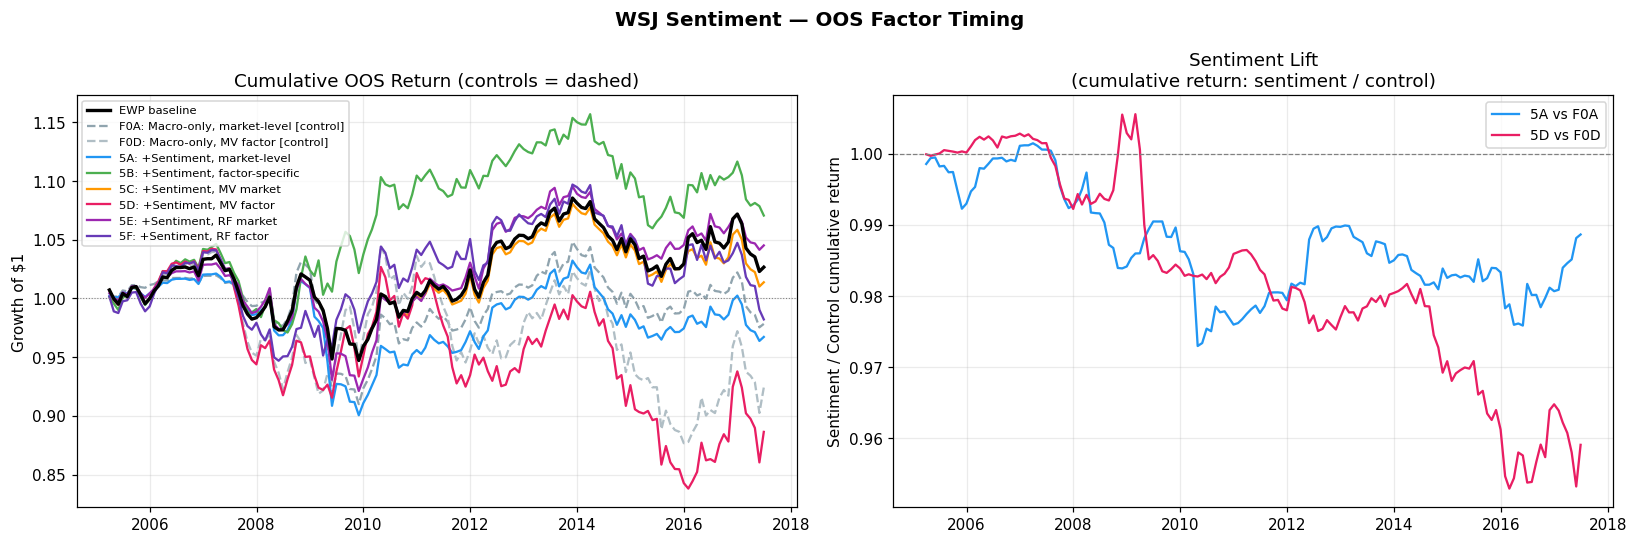

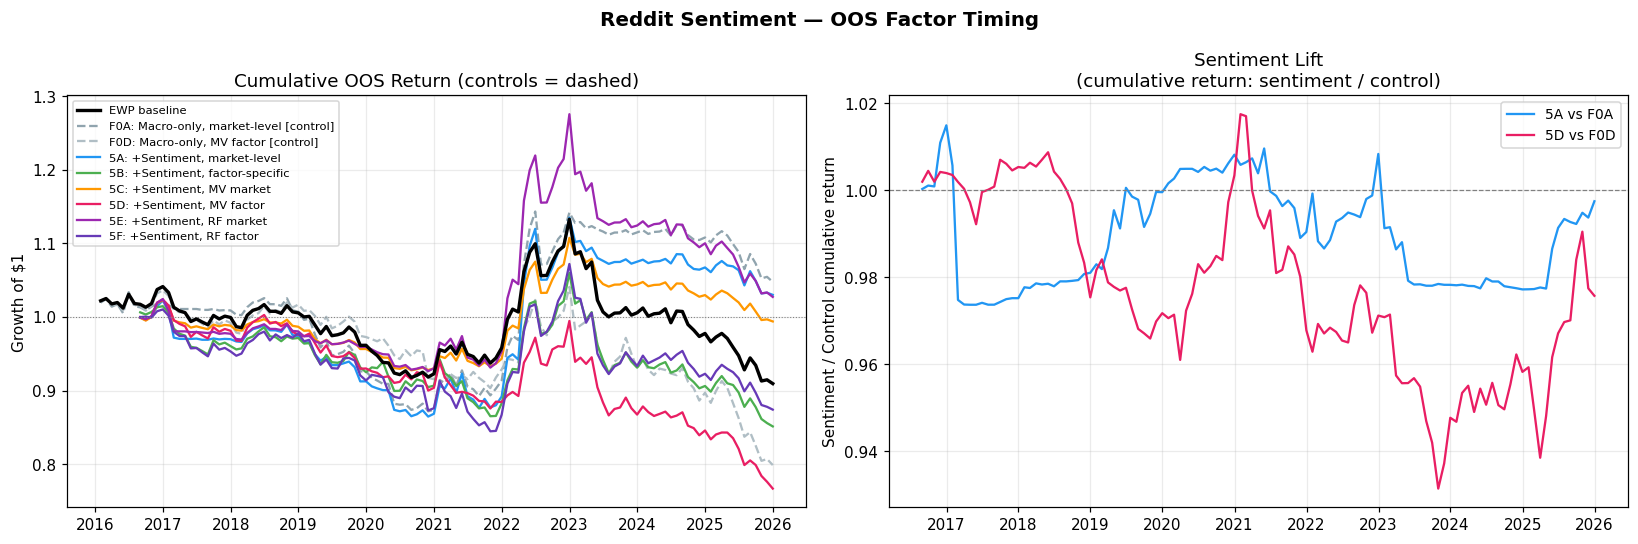

In [10]:
model_colors = {
    'EWP':              'black',
    'F0A_macro_market': '#90A4AE',
    'F0D_macro_mv':     '#B0BEC5',
    '5A_signal_market': '#2196F3',
    '5B_signal_factor': '#4CAF50',
    '5C_mv_market':     '#FF9800',
    '5D_mv_factor':     '#E91E63',
    '5E_rf_market':     '#9C27B0',
    '5F_rf_factor':     '#673AB7',
}
model_labels = {
    'EWP':              'EWP baseline',
    'F0A_macro_market': 'F0A: Macro-only, market-level [control]',
    'F0D_macro_mv':     'F0D: Macro-only, MV factor [control]',
    '5A_signal_market': '5A: +Sentiment, market-level',
    '5B_signal_factor': '5B: +Sentiment, factor-specific',
    '5C_mv_market':     '5C: +Sentiment, MV market',
    '5D_mv_factor':     '5D: +Sentiment, MV factor',
    '5E_rf_market':     '5E: +Sentiment, RF market',
    '5F_rf_factor':     '5F: +Sentiment, RF factor',
}
model_ls = {k: '--' if k.startswith('F0') else '-' for k in model_colors}
model_ls['EWP'] = '-'

for source in ['WSJ', 'Reddit']:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{source} Sentiment — OOS Factor Timing', fontsize=13, fontweight='bold')

    # (a) Cumulative returns
    ax = axes[0]
    bench_r   = oos_series.get(f'{source}_EWP', pd.Series())
    all_keys  = [f'{source}_{m}' for m in ALL_MODELS if f'{source}_{m}' in oos_series
                 and len(oos_series[f'{source}_{m}']) > 0]
    if not all_keys:
        ax.set_title('No OOS results')
    else:
        first_oos = min(oos_series[k].index[0] for k in all_keys)
        bench_oos = bench_r[bench_r.index >= first_oos].dropna()
        ax.plot(bench_oos.index, (1 + bench_oos).cumprod().values,
                color='black', linewidth=2.2, label='EWP baseline', zorder=5)
        for mname in ALL_MODELS:
            key = f'{source}_{mname}'
            if key not in oos_series or len(oos_series[key]) == 0: continue
            r = oos_series[key].dropna()
            ax.plot(r.index, (1 + r).cumprod().values,
                    color=model_colors.get(mname, 'grey'),
                    linestyle=model_ls.get(mname, '-'),
                    linewidth=1.5,
                    label=model_labels.get(mname, mname))
        ax.axhline(1, color='grey', linewidth=0.7, linestyle=':')
        ax.set_title('Cumulative OOS Return (controls = dashed)')
        ax.set_ylabel('Growth of $1')
        ax.legend(fontsize=7.5, loc='upper left')
        ax.grid(alpha=0.25)

    # (b) Sentiment lift: (sentiment model) / (control model)
    ax2 = axes[1]
    ax2.set_title('Sentiment Lift\n(cumulative return: sentiment / control)')
    for sent_m, ctrl_m, color, lbl in [
        ('5A_signal_market', 'F0A_macro_market', '#2196F3', '5A vs F0A'),
        ('5D_mv_factor',     'F0D_macro_mv',     '#E91E63', '5D vs F0D'),
    ]:
        r_sent = oos_series.get(f'{source}_{sent_m}')
        r_ctrl = oos_series.get(f'{source}_{ctrl_m}')
        if r_sent is None or r_ctrl is None: continue
        aligned = pd.concat([r_sent, r_ctrl], axis=1).dropna()
        if aligned.empty: continue
        aligned.columns = ['sent', 'ctrl']
        lift = (1 + aligned['sent']).cumprod() / (1 + aligned['ctrl']).cumprod()
        ax2.plot(lift.index, lift.values, color=color, linewidth=1.5, label=lbl)
    ax2.axhline(1.0, color='grey', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('Sentiment / Control cumulative return')
    ax2.legend(fontsize=9)
    ax2.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

### 10b. Factor Weight Evolution

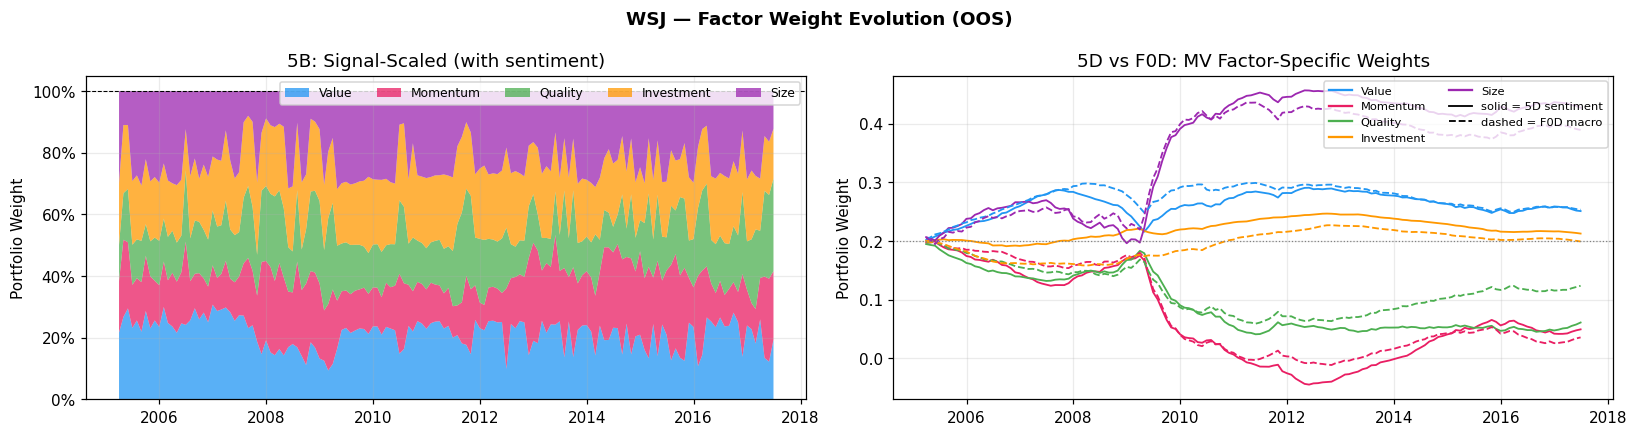

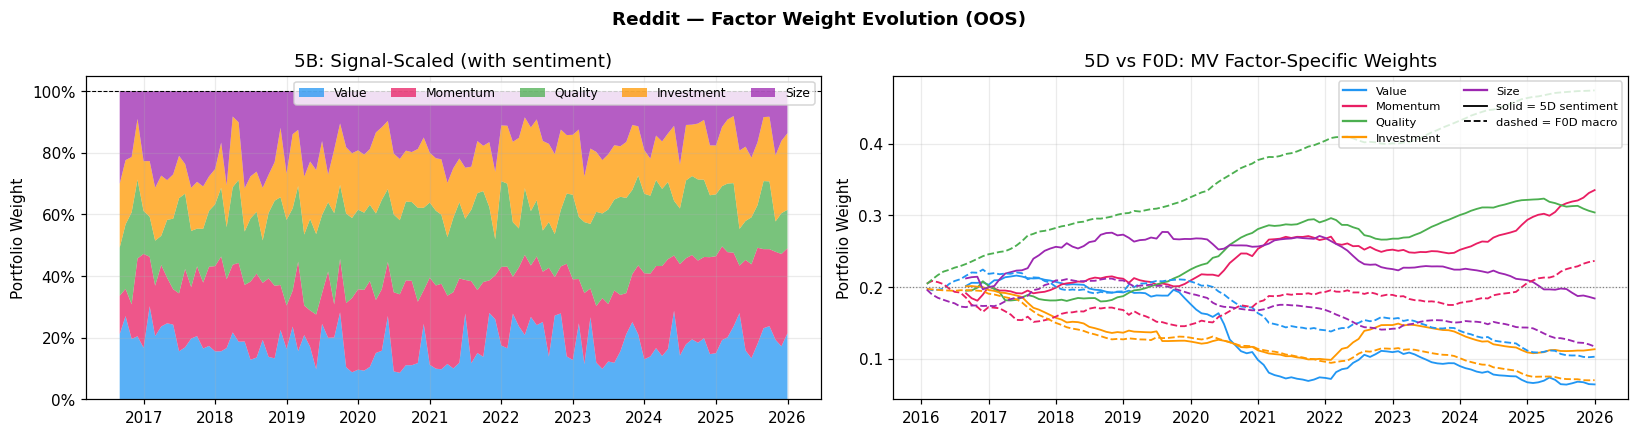

In [11]:
from matplotlib.lines import Line2D
colors5 = ['#2196F3', '#E91E63', '#4CAF50', '#FF9800', '#9C27B0']

for source in ['WSJ', 'Reddit']:
    key_5b  = f'{source}_5B_signal_factor'
    key_5d  = f'{source}_5D_mv_factor'
    key_f0d = f'{source}_F0D_macro_mv'

    if key_5b not in oos_wts_all and key_5d not in oos_wts_all:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))
    fig.suptitle(f'{source} — Factor Weight Evolution (OOS)', fontsize=12, fontweight='bold')
    fac_labels_avail = [lbl for lbl, c in zip(FACTOR_LABELS, FACTOR_COLS) if c in df.columns]

    # 5B: stacked area
    if key_5b in oos_wts_all:
        wts = oos_wts_all[key_5b].copy()
        wts.columns = fac_labels_avail[:wts.shape[1]]
        axes[0].stackplot(wts.index, wts.T.values,
                          labels=wts.columns, colors=colors5[:wts.shape[1]], alpha=0.75)
        axes[0].axhline(1.0, color='black', linewidth=0.7, linestyle='--')
        axes[0].set_title('5B: Signal-Scaled (with sentiment)')
        axes[0].set_ylabel('Portfolio Weight')
        axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
        axes[0].legend(loc='upper right', fontsize=8, ncol=wts.shape[1])
        axes[0].grid(alpha=0.25)

    # 5D vs F0D line plot
    ax2 = axes[1]
    for plot_key, lstyle, llbl in [(key_5d, '-', '5D'), (key_f0d, '--', 'F0D')]:
        if plot_key not in oos_wts_all: continue
        wts = oos_wts_all[plot_key].copy()
        wts.columns = fac_labels_avail[:wts.shape[1]]
        for col, color in zip(wts.columns, colors5):
            ax2.plot(wts.index, wts[col], color=color, linestyle=lstyle, linewidth=1.2,
                     label=f'{col} ({llbl})' if lstyle == '-' else None)
    ax2.axhline(0.2, color='grey', linewidth=0.8, linestyle=':', label='EWP (1/5)')
    ax2.set_title('5D vs F0D: MV Factor-Specific Weights')
    ax2.set_ylabel('Portfolio Weight')
    legend_els = [Line2D([0],[0], color=c, lw=1.5, label=l)
                  for c, l in zip(colors5, fac_labels_avail)]
    legend_els += [
        Line2D([0],[0], color='k', lw=1.2, linestyle='-',  label='solid = 5D sentiment'),
        Line2D([0],[0], color='k', lw=1.2, linestyle='--', label='dashed = F0D macro'),
    ]
    ax2.legend(handles=legend_els, fontsize=7.5, loc='upper right', ncol=2)
    ax2.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

### 10c. Sentiment Signal vs Next-Month Portfolio Return

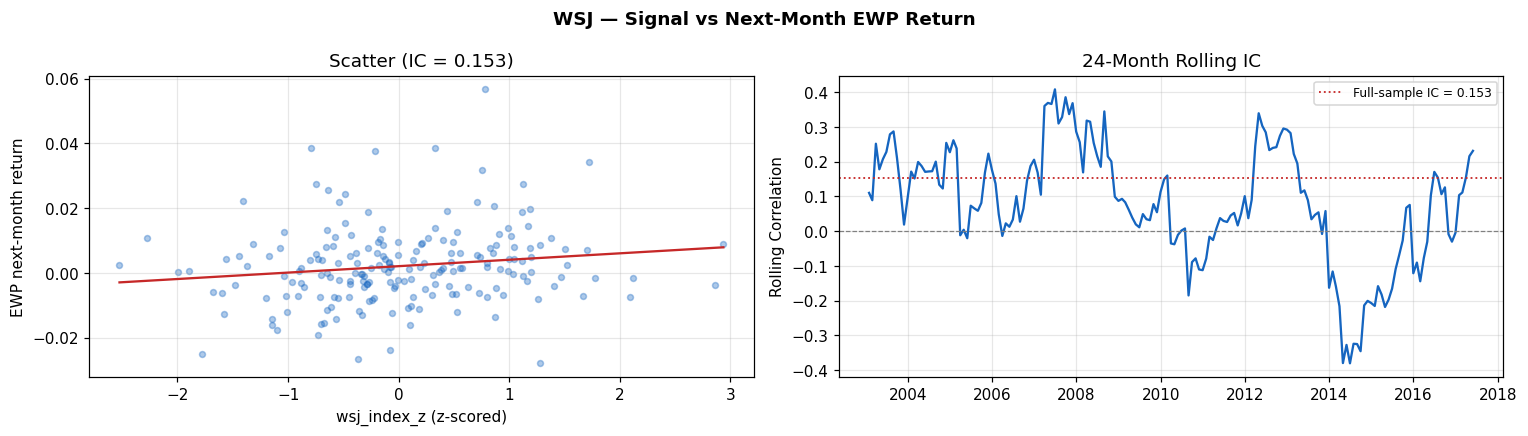

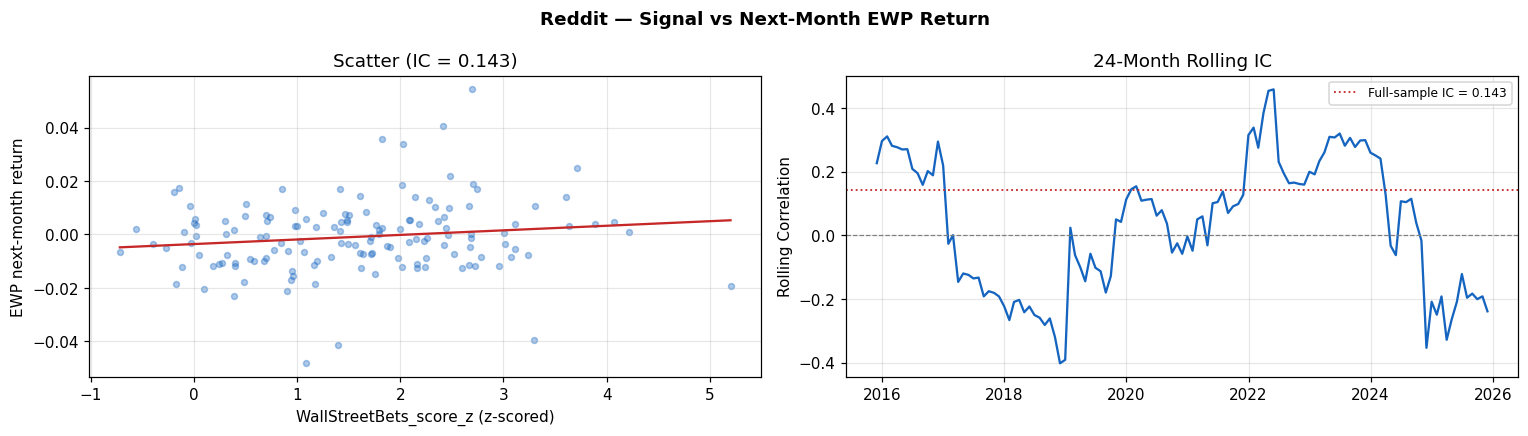

In [12]:
for cfg, df_win, sent_z_cols in [
    (CFG_WSJ,    df_wsj,    wsj_z_cols),
    (CFG_REDDIT, df_reddit, reddit_z_cols),
]:
    if not sent_z_cols:
        continue
    bench          = make_ewp(df_win, FACTOR_COLS)
    first_sent_col = sent_z_cols[0]
    if first_sent_col not in df_win.columns:
        continue

    signal   = df_win[first_sent_col].dropna()
    ret_next = bench.shift(-1)
    combined = pd.concat([signal, ret_next], axis=1).dropna()
    combined.columns = ['Signal', 'Next Return']

    rolling_corr = combined['Signal'].rolling(24).corr(combined['Next Return'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{cfg["name"]} — Signal vs Next-Month EWP Return', fontsize=12, fontweight='bold')

    axes[0].scatter(combined['Signal'], combined['Next Return'],
                    alpha=0.35, s=15, color='#1565C0')
    m, b = np.polyfit(combined['Signal'], combined['Next Return'], 1)
    xs = np.linspace(combined['Signal'].min(), combined['Signal'].max(), 50)
    axes[0].plot(xs, m * xs + b, color='#C62828', linewidth=1.5)
    ic_full = combined['Signal'].corr(combined['Next Return'])
    axes[0].set_title(f'Scatter (IC = {ic_full:.3f})')
    axes[0].set_xlabel(f'{first_sent_col} (z-scored)')
    axes[0].set_ylabel('EWP next-month return')
    axes[0].grid(alpha=0.3)

    axes[1].plot(rolling_corr.index, rolling_corr.values, color='#1565C0', linewidth=1.5)
    axes[1].axhline(0, color='grey', linewidth=0.8, linestyle='--')
    axes[1].axhline(ic_full, color='#C62828', linewidth=1.2, linestyle=':',
                    label=f'Full-sample IC = {ic_full:.3f}')
    axes[1].set_title('24-Month Rolling IC')
    axes[1].set_ylabel('Rolling Correlation')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()